#  Netflix Content Evolution: A Data-Driven Analysis of Movies and TV Shows

## Data Visualization Final Individual Project

### Student Information

**Name:** Asala Nithish

**Course:** Data Visualization

**Semester:** Summer 2026

**University:** University of Europe for Applied Sciences (UE)

---

## Project Overview

Netflix is one of the world's largest streaming platforms, offering thousands of movies and TV shows from different countries and genres. This project explores the Netflix content library to identify trends, patterns, and insights related to content type, country, genre, ratings, release years, and growth over time.

The analysis is performed using **Python**, **Pandas**, and **Plotly**, following the principles of effective data visualization and storytelling.

In [1]:
# ======================================================
# Import Required Libraries
# ======================================================

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ======================================================
# Load Dataset
# ======================================================

df = pd.read_csv("../data/netflix_titles.csv")

In [3]:
# Display the first five rows

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Dataset Dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 8807
Columns : 12


In [5]:
# Display Column Names

df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

# Data Understanding and Cleaning

Before performing any analysis, the dataset must be explored and cleaned. This step helps identify missing values, duplicate records, incorrect data types, and other issues that may affect the analysis. A clean dataset ensures accurate and meaningful visualizations.

In [6]:
# ======================================================
# Dataset Information
# ======================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
# ======================================================
# Statistical Summary
# ======================================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# ======================================================
# Missing Values
# ======================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean() * 100, 2)
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [9]:
# ======================================================
# Duplicate Records
# ======================================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [10]:
# ======================================================
# Remove Duplicate Records
# ======================================================

df.drop_duplicates(inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (8807, 12)


In [11]:
# ======================================================
# Convert Date Column
# ======================================================

# Remove leading and trailing spaces
df["date_added"] = df["date_added"].str.strip()

# Convert to datetime
df["date_added"] = pd.to_datetime(df["date_added"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [13]:
print(df["date_added"].dtype)

datetime64[ns]


In [14]:
df["date_added"].head(10)

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
5   2021-09-24
6   2021-09-24
7   2021-09-24
8   2021-09-24
9   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [16]:
# Duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [17]:
# Remove duplicates

df.drop_duplicates(inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (8807, 12)


# Feature Engineering

Feature engineering is the process of creating new variables from existing data.

These new variables help in understanding trends and performing meaningful analysis.

In [18]:
# ======================================================
# Extract Year Added
# ======================================================

df["year_added"] = df["date_added"].dt.year

In [19]:
# ======================================================
# Extract Month Added
# ======================================================

df["month_added"] = df["date_added"].dt.month_name()

In [20]:
# ======================================================
# Extract Month Number
# ======================================================

df["month_number"] = df["date_added"].dt.month

In [21]:
# ======================================================
# Content Age
# ======================================================

df["content_age"] = (
    df["year_added"] - df["release_year"]
)

In [22]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_number,content_age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,9.0,1.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,9.0,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,9.0,0.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,9.0,0.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,9.0,0.0


# Question 1

## What is the distribution of Movies and TV Shows on Netflix?

This visualization compares the number of Movies and TV Shows available on Netflix. It helps understand which type of content dominates the platform.

In [24]:
# ======================================================
# Movies vs TV Shows
# ======================================================

content_count = df["type"].value_counts()

content_count

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

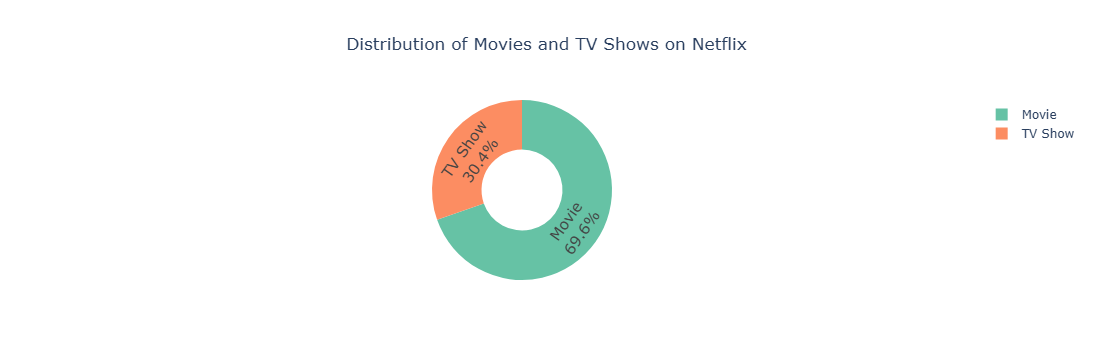

In [26]:
import plotly.express as px

fig = px.pie(
    values=content_count.values,
    names=content_count.index,
    title="Distribution of Movies and TV Shows on Netflix",
    hole=0.45,
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(
    textinfo="percent+label",
    textfont_size=15
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

### Interpretation

The chart shows that Movies make up the majority of Netflix's content library, while TV Shows represent a smaller share.

This indicates that Netflix has historically focused more on movie content than television series.

# Question 2

## How has Netflix's content library grown over the years?

This analysis examines the number of titles added to Netflix each year. It helps identify periods of rapid growth and changes in Netflix's content acquisition strategy.

In [27]:
# ======================================================
# Content Added Per Year
# ======================================================

yearly_content = (
    df.groupby("year_added")
      .size()
      .reset_index(name="Number of Titles")
)

yearly_content

,year_added,Number of Titles
0,2008.0,2
1,2009.0,2
2,2010.0,1
3,2011.0,13
4,2012.0,3
5,2013.0,11
6,2014.0,24
7,2015.0,82
8,2016.0,429
9,2017.0,1188


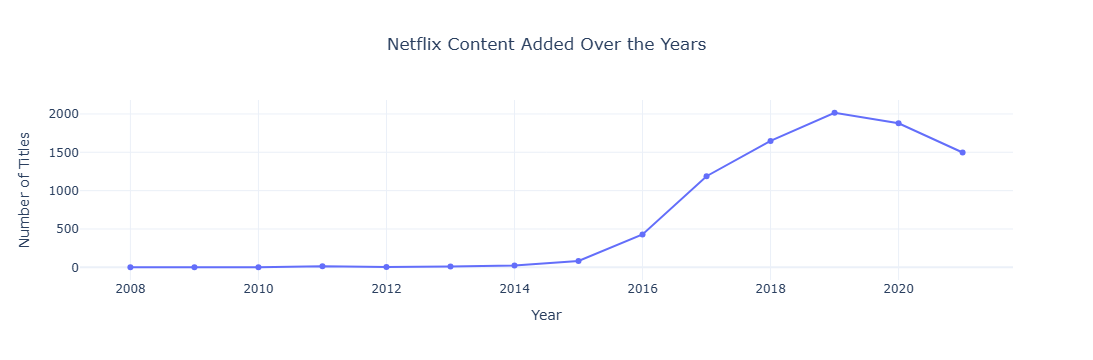

In [28]:
fig = px.line(
    yearly_content,
    x="year_added",
    y="Number of Titles",
    markers=True,
    title="Netflix Content Added Over the Years"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Number of Titles",
    template="plotly_white"
)

fig.show()

### Interpretation

- Netflix's content library grew steadily over the years.
- A rapid increase in content additions can be observed after 2015.
- The platform experienced its highest growth between 2018 and 2020.
- This reflects Netflix's expansion into global content production and licensing.

# Question 3

## Which countries contribute the most content to Netflix?

This analysis identifies the countries that have contributed the highest number of Movies and TV Shows to Netflix. It helps understand Netflix's global content distribution.

In [29]:
# ======================================================
# Top 10 Countries
# ======================================================

country_count = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

country_count

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

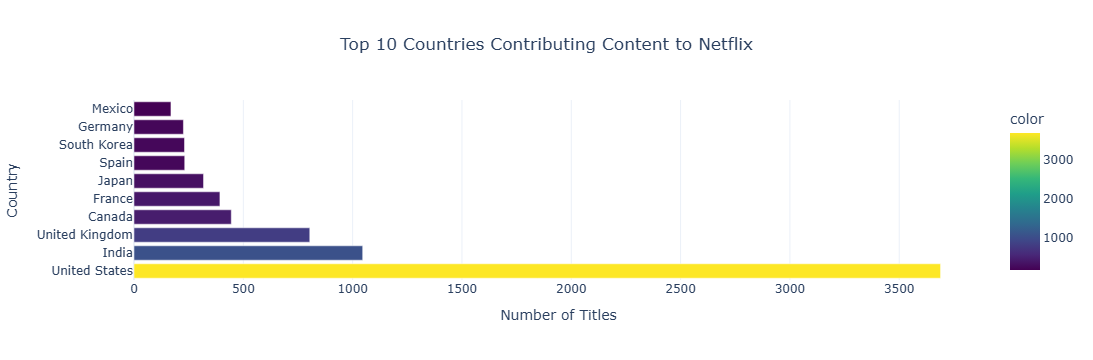

In [30]:
fig = px.bar(
    x=country_count.values,
    y=country_count.index,
    orientation="h",
    title="Top 10 Countries Contributing Content to Netflix",
    labels={
        "x": "Number of Titles",
        "y": "Country"
    },
    color=country_count.values,
    color_continuous_scale="Viridis"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

### Interpretation

- The United States contributes the largest number of titles to Netflix.
- India ranks among the top content-producing countries.
- The results show Netflix's strong presence in North America while also highlighting its growing investment in international markets.

# Question 4

## What are the most popular genres on Netflix?

This analysis identifies the genres that appear most frequently in Netflix's content library.

In [31]:
# ======================================================
# Top 10 Genres
# ======================================================

genre_count = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

genre_count

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

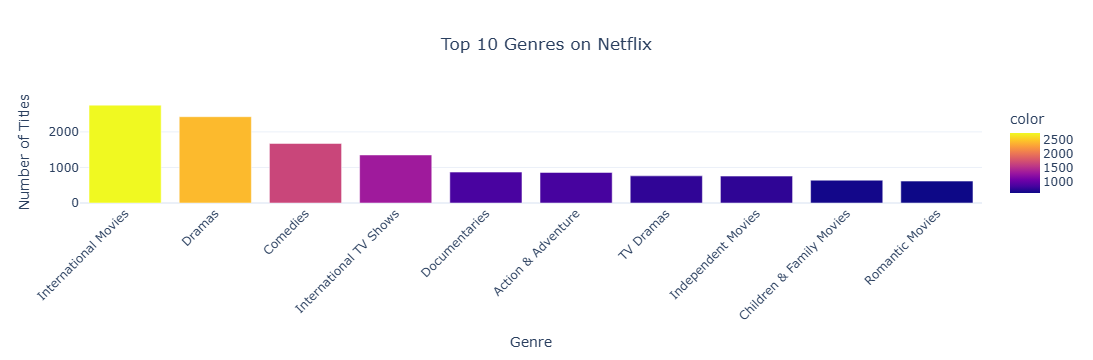

In [32]:
fig = px.bar(
    x=genre_count.index,
    y=genre_count.values,
    title="Top 10 Genres on Netflix",
    labels={
        "x": "Genre",
        "y": "Number of Titles"
    },
    color=genre_count.values,
    color_continuous_scale="Plasma"
)

fig.update_layout(
    title_x=0.5,
    xaxis_tickangle=-45,
    template="plotly_white"
)

fig.show()

### Interpretation

- International Movies and Dramas are among the most common genres.
- Netflix offers content across a wide variety of genres to appeal to different audiences.
- The platform has a strong focus on international entertainment.

# Question 5

## What are the most common content ratings on Netflix?

Content ratings help classify movies and TV shows according to their target audience. This analysis identifies the most frequently occurring ratings available on Netflix.

In [33]:
# ======================================================
# Content Ratings Distribution
# ======================================================

rating_count = df["rating"].value_counts()

rating_count

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

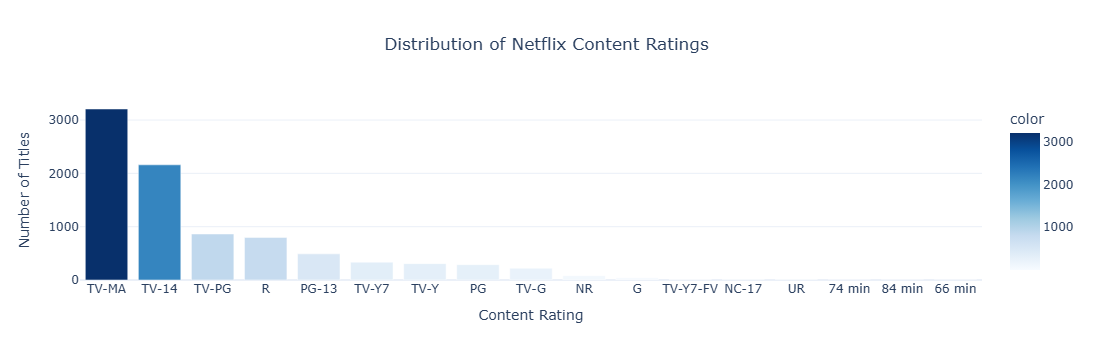

In [34]:
fig = px.bar(
    x=rating_count.index,
    y=rating_count.values,
    title="Distribution of Netflix Content Ratings",
    labels={
        "x": "Content Rating",
        "y": "Number of Titles"
    },
    color=rating_count.values,
    color_continuous_scale="Blues"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

### Interpretation

- TV-MA is the most common content rating on Netflix.
- TV-14 and TV-PG also represent a large portion of the content.
- This suggests that Netflix mainly targets teenage and adult audiences.

# Question 6

## What is the distribution of movie durations?

This analysis explores how long Netflix movies typically are and identifies the most common movie durations.

In [37]:
# ======================================================
# Movie Duration Analysis
# ======================================================

movies = df[df["type"] == "Movie"].copy()

# Remove rows where duration is missing
movies = movies.dropna(subset=["duration"])

# Remove the text " min"
movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)

# Convert to numeric
movies["duration"] = pd.to_numeric(
    movies["duration"],
    errors="coerce"
)

# Remove any invalid values
movies = movies.dropna(subset=["duration"])

# Convert to integer
movies["duration"] = movies["duration"].astype(int)

movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_number,content_age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,9.0,1.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,September,9.0,0.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,September,9.0,28.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,September,9.0,0.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,September,9.0,0.0


In [38]:
movies["duration"].isna().sum()

np.int64(0)

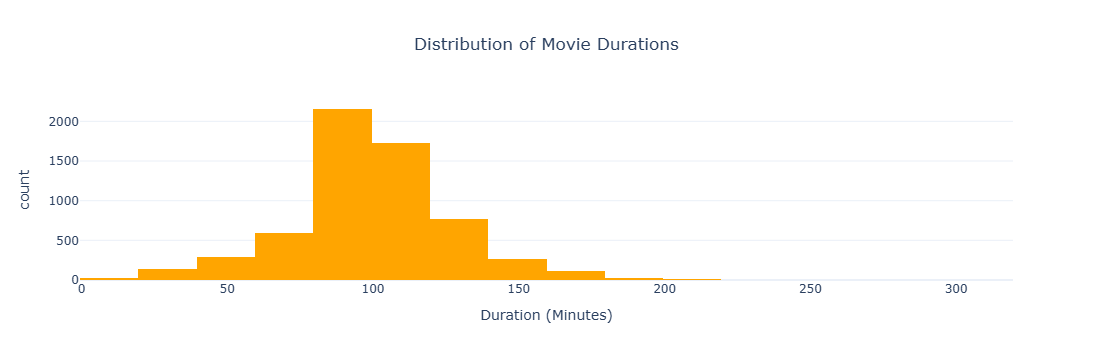

In [39]:
fig = px.histogram(
    movies,
    x="duration",
    nbins=30,
    title="Distribution of Movie Durations",
    labels={"duration": "Duration (Minutes)"},
    color_discrete_sequence=["orange"]
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

# Question 7

## How many seasons do Netflix TV Shows have?

This analysis examines the number of seasons available for TV shows on Netflix.

In [41]:
# ======================================================
# TV Show Seasons Analysis
# ======================================================

tv = df[df["type"] == "TV Show"].copy()

# Remove missing values
tv = tv.dropna(subset=["duration"])

# Remove the words "Season" and "Seasons"
tv["duration"] = tv["duration"].str.replace(" Seasons", "", regex=False)
tv["duration"] = tv["duration"].str.replace(" Season", "", regex=False)

# Convert to numeric
tv["duration"] = pd.to_numeric(tv["duration"], errors="coerce")

# Remove invalid values
tv = tv.dropna(subset=["duration"])

# Convert to integer
tv["duration"] = tv["duration"].astype(int)

tv.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_number,content_age
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,9.0,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,9.0,0.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,9.0,0.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,9.0,0.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0,September,9.0,0.0


In [42]:
season_count = tv["duration"].value_counts().sort_index()

season_count

duration
1     1793
2      425
3      199
4       95
5       65
6       33
7       23
8       17
9        9
10       7
11       2
12       2
13       3
15       2
17       1
Name: count, dtype: int64

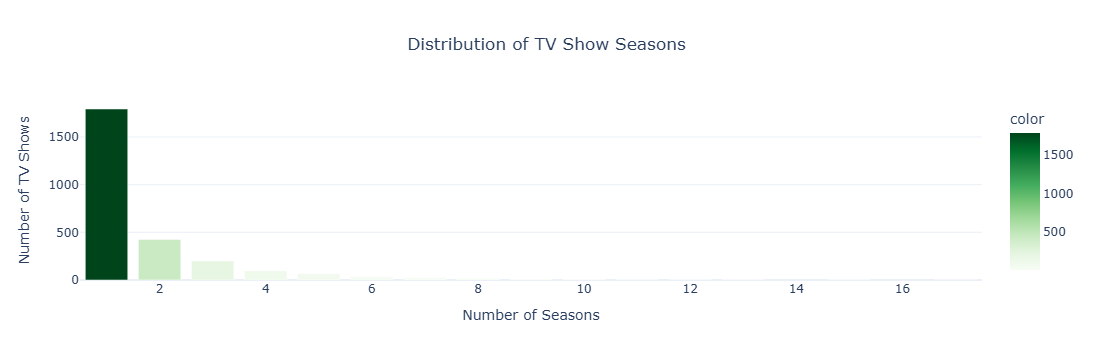

In [43]:
fig = px.bar(
    x=season_count.index,
    y=season_count.values,
    title="Distribution of TV Show Seasons",
    labels={
        "x": "Number of Seasons",
        "y": "Number of TV Shows"
    },
    color=season_count.values,
    color_continuous_scale="Greens"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

### Interpretation

- Most TV Shows on Netflix have only one season.
- The number of TV Shows decreases as the number of seasons increases.
- This indicates that Netflix has many limited series and newer shows with fewer seasons.

# Question 8

## Which month has the highest number of content additions?

This analysis identifies the months in which Netflix added the highest number of titles to its platform.

In [44]:
# ======================================================
# Monthly Content Additions
# ======================================================

monthly_content = (
    df.groupby(["month_number", "month_added"])
      .size()
      .reset_index(name="Number of Titles")
)

monthly_content = monthly_content.sort_values("month_number")

monthly_content

,month_number,month_added,Number of Titles
0,1.0,January,738
1,2.0,February,563
2,3.0,March,742
3,4.0,April,764
4,5.0,May,632
5,6.0,June,728
6,7.0,July,827
7,8.0,August,755
8,9.0,September,770
9,10.0,October,760


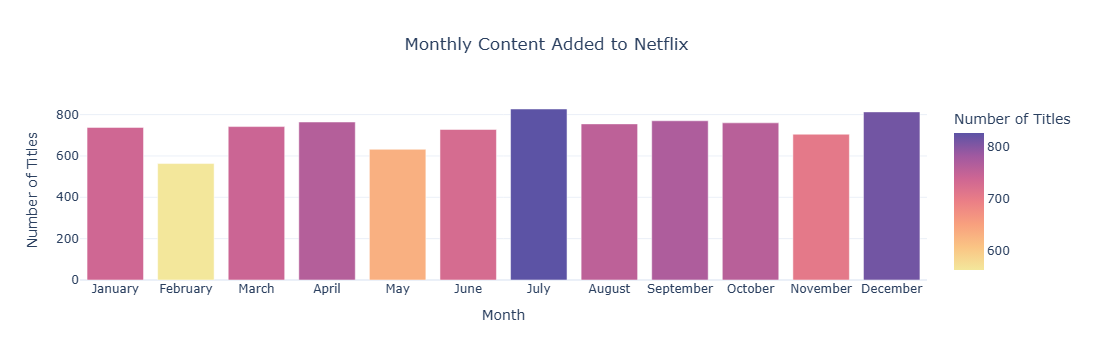

In [45]:
fig = px.bar(
    monthly_content,
    x="month_added",
    y="Number of Titles",
    title="Monthly Content Added to Netflix",
    color="Number of Titles",
    color_continuous_scale="Sunset"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Number of Titles",
    template="plotly_white"
)

fig.show()

### Interpretation

- Netflix adds content throughout the year.
- Some months have noticeably higher content additions.
- This may be related to seasonal releases or licensing schedules.

# Question 9

## How old is the content when Netflix adds it?

This analysis measures the difference between the release year and the year the content was added to Netflix.

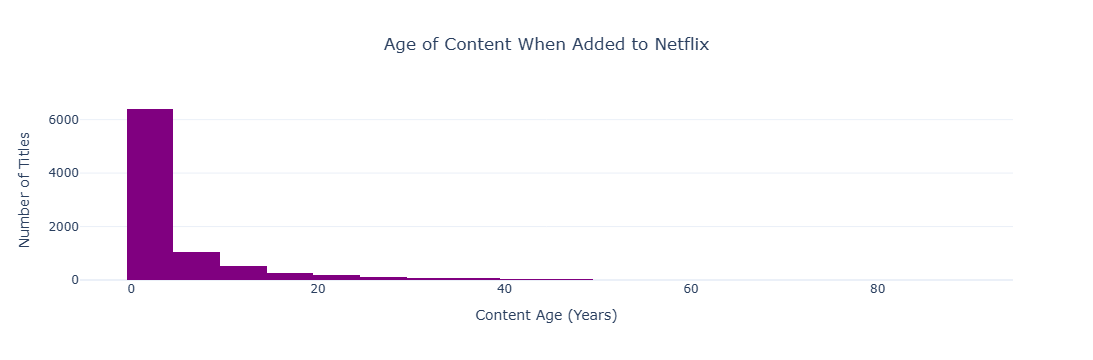

In [46]:
fig = px.histogram(
    df,
    x="content_age",
    nbins=25,
    title="Age of Content When Added to Netflix",
    color_discrete_sequence=["purple"]
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Content Age (Years)",
    yaxis_title="Number of Titles",
    template="plotly_white"
)

fig.show()

### Interpretation

- Most content is added to Netflix within a few years of its original release.
- Older content is also available, but in smaller quantities.
- This shows that Netflix balances recent releases with classic titles.

# Question 10

## How have Movies and TV Shows grown over the years?

This analysis compares yearly additions of Movies and TV Shows to understand how Netflix's content strategy has evolved.

In [47]:
growth = (
    df.groupby(["year_added", "type"])
      .size()
      .reset_index(name="Titles")
)

growth.head()

,year_added,type,Titles
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13


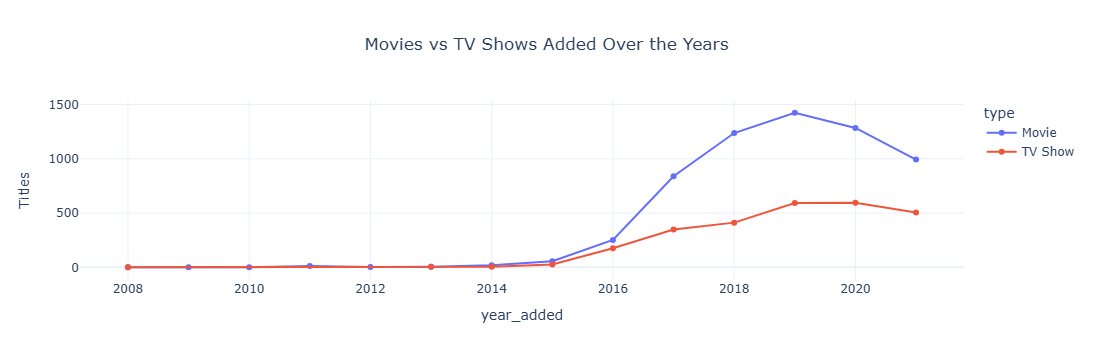

In [48]:
fig = px.line(
    growth,
    x="year_added",
    y="Titles",
    color="type",
    markers=True,
    title="Movies vs TV Shows Added Over the Years"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

### Interpretation

- Movies have consistently made up the majority of Netflix's additions.
- TV Shows have grown significantly over time, especially in recent years.
- This reflects Netflix's increased investment in original television series and international productions.

# Conclusion

This project analyzed Netflix's content library using Python, Pandas, and Plotly.

The analysis revealed several important insights:

- Movies make up a larger portion of Netflix's catalog than TV Shows.
- Netflix experienced rapid growth in content additions after 2015.
- The United States contributes the highest number of titles, followed by other countries such as India.
- International Movies and Dramas are among the most popular genres.
- Most content is intended for teenage and adult audiences.
- Most movies have durations between 80 and 120 minutes.
- Most TV Shows have only one season.
- Netflix adds content throughout the year while maintaining a balance between newly released and older titles.

Overall, the project demonstrates how interactive data visualization can transform raw data into meaningful business insights.